# Projekt: Detekcja Phishingu na Podstawie Cech URL

## Cel Projektu
Zbudowanie modelu uczenia maszynowego do klasyfikacji URL jako phishing lub legalny.

## Dataset
- **Źródło:** UCI Phishing Websites Dataset (Kaggle)
- **Zawartość:** 235,795 wierszy z cechami URL
- **Cechy:** Długość URL, liczba poddomeny, obecność IP, TLD, HTTPS, itp.

## Metody
1. **Logistic Regression** - liniowy model bazowy
2. **Random Forest** - ensemble method, bardziej zaawansowany

## Metryki Ewaluacji
- Accuracy (dokładność ogólna)
- Precision (precyzja dla klasy phishing)
- Recall (pełność dla klasy phishing)
- F1-Score (średnia harmoniczna)
- Confusion Matrix (macierz pomyłek)
- ROC/AUC (krzywa ROC i pole pod krzywą)
- Cross-validation (5-fold validation)
- Feature Importance (ważność cech)

## Inicjalizacja

Importowanie wszystkich niezbędnych bibliotek i funkcji pomocniczych.

In [2]:
from config import DEFAULT_LABEL_COL, DEFAULT_URL_COL
from data_io import load_df
from eda import quick_eda
from features import prepare_features
from feature_selection import select_url_only_features
from preprocessing import deduplicate_and_split_safe
from noise_injection import inject_realistic_noise
from models import train_models
from evaluation import evaluate_models
from roc_analysis import run_roc_auc_analysis
from feature_importance import analyze_feature_importance
from cross_validation import run_cross_validation
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)

COLORS = {
    'phishing': '#FF6B6B',
    'legitimate': '#4ECDC4',
    'train': '#3498DB',
    'test': '#E74C3C',
    'model1': '#3498DB',
    'model2': '#E74C3C',
}

print("Wszystkie biblioteki zaladowane pomyslnie")
print("Matplotlib & Seaborn gotowe!")

c:\Users\bdutka\Desktop\phishing-detector\phishing-detector\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Wszystkie biblioteki zaladowane pomyslnie
Matplotlib & Seaborn gotowe!


---
# ETAP 1-2: Załadowanie i Wczytanie Danych

Pobieramy dataset z Kaggle i wczytujemy go do pamięci.
Sprawdzamy podstawowe informacje: liczbę wierszy, kolumn oraz kilka pierwszych obserwacji.

In [3]:
print("\n" + "="*80)
print("KROK 1-2: ZAŁADOWANIE I WCZYTANIE DANYCH")
print("="*80)

print("\nKrok 1: Ładowanie dataset...")
df = load_df()
print("Dataset załadowany pomyślnie\n")

print("-"*80)
print("INFORMACJE O DATASECIE")
print("-"*80)

print(f"\nRozmiar: {df.shape[0]:,} wierszy x {df.shape[1]} kolumn")
print(f"\nPierwsze 5 wierszy:")
print(df.head().to_string())

print(f"\nTypy danych:")
for col, dtype in df.dtypes.items():
    print(f"  {col:30s} {str(dtype):15s}")

print(f"\nBrakujące wartości:")
missing = df.isnull().sum().sum()
print(f"  Brak" if missing == 0 else f"  {missing} komórek")

print(f"\nRozkład klas:")
if DEFAULT_LABEL_COL in df.columns:
    for label, count in df[DEFAULT_LABEL_COL].value_counts().sort_index().items():
        pct = (count / len(df)) * 100
        print(f"  Klasa {label}: {count:,} ({pct:.1f}%)")
else:
    print(f"  Kolumna '{DEFAULT_LABEL_COL}' nie znaleziona")

print("\nZaładowanie zakończone\n")


KROK 1-2: ZAŁADOWANIE I WCZYTANIE DANYCH

Krok 1: Ładowanie dataset...
Dataset załadowany pomyślnie

--------------------------------------------------------------------------------
INFORMACJE O DATASECIE
--------------------------------------------------------------------------------

Rozmiar: 235,795 wierszy x 55 kolumn

Pierwsze 5 wierszy:
                                  URL  URLLength                      Domain  DomainLength  IsDomainIP  TLD  URLSimilarityIndex  CharContinuationRate  TLDLegitimateProb  URLCharProb  TLDLength  NoOfSubDomain  HasObfuscation  NoOfObfuscatedChar  ObfuscationRatio  NoOfLettersInURL  LetterRatioInURL  NoOfDegitsInURL  DegitRatioInURL  NoOfEqualsInURL  NoOfQMarkInURL  NoOfAmpersandInURL  NoOfOtherSpecialCharsInURL  SpacialCharRatioInURL  IsHTTPS  LineOfCode  LargestLineLength  HasTitle                                                                                                                                                                         

---
# ETAP 3: Analiza Eksploracyjna Danych (EDA)

Sprawdzamy strukturę danych:
- Brakujące wartości
- Typy danych (int, float, string)
- Rozkład klas (phishing vs legalny)

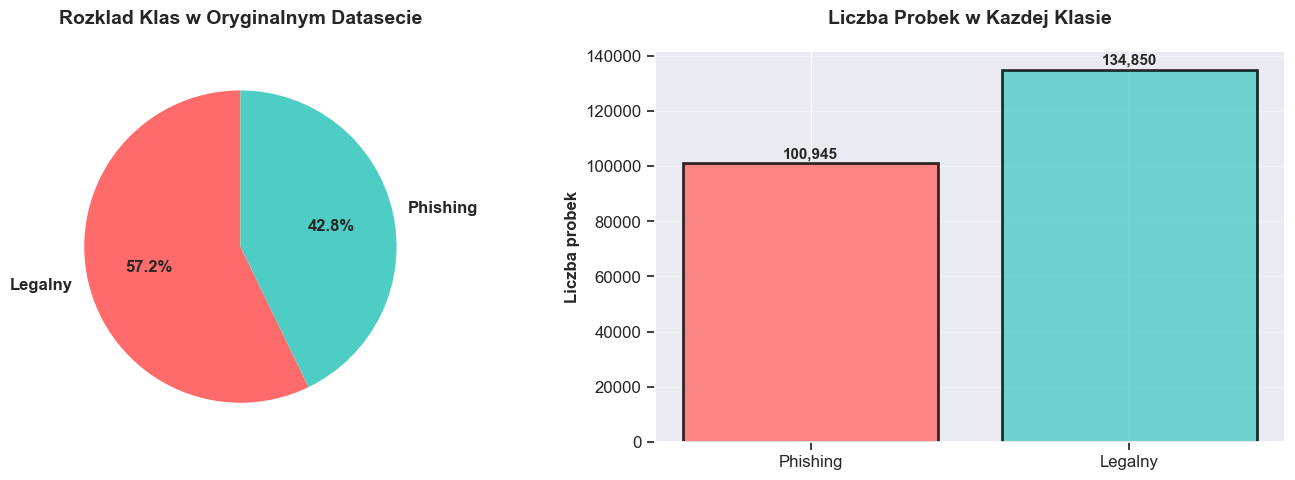

Wykres rozkladu klas zapisany


In [4]:
# Wizualizacja rozkladu klas w oryginalnym datasecie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['label'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
axes[0].pie(class_counts.values, labels=['Legalny', 'Phishing'], autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('Rozklad Klas w Oryginalnym Datasecie', fontsize=14, weight='bold', pad=20)

class_names = ['Phishing', 'Legalny']
counts = [class_counts[0], class_counts[1]]
axes[1].bar(class_names, counts, color=colors, edgecolor='black', linewidth=2, alpha=0.8)
axes[1].set_ylabel('Liczba probek', fontsize=12, weight='bold')
axes[1].set_title('Liczba Probek w Kazdej Klasie', fontsize=14, weight='bold', pad=20)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(counts):
    axes[1].text(i, v + 2000, f'{v:,}', ha='center', fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig('outputs/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Wykres rozkladu klas zapisany")

---
# ETAP 4-5: Preprocessing i Przygotowanie Cech

Przygotowujemy dane do modelowania:
1. Usuwamy duplikaty URL
2. Ekstraktujemy cechy numeryczne
3. Pozostawiamy TYLKO cechy związane ze strukturą URL

Cechy URL zawierają informacje takie jak:
- Długość URL
- Liczba poddomeny
- Obecność IP zamiast domeny
- Długość TLD (top-level domain)
- Charakter URL (obfuscation, special characters)
- Czy używa HTTPS

In [5]:
print("\n" + "="*80)
print("KROK 4-5: PREPROCESSING I PRZYGOTOWANIE CECH")
print("="*80)

print("\nKrok 4a: Usuwanie duplikatów...")
df = deduplicate_and_split_safe(df, url_col=DEFAULT_URL_COL)
print(f"Pozostało: {df.shape[0]:,} wierszy")

print("\nKrok 4b: Ekstraktowanie cech numerycznych...")
X, y = prepare_features(df, label_col=DEFAULT_LABEL_COL, url_col=DEFAULT_URL_COL)
print(f"Liczba cech: {X.shape[1]}")
print(f"Liczba próbek: {X.shape[0]:,}")

print("\nKrok 5: Selekcja TYLKO cech URL (bez zawartości strony)...")
X = select_url_only_features(X)

print(f"\nCechy do modelowania ({X.shape[1]} total):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nRozkład klas:")
print(f"  Phishing (0): {(y == 0).sum():,} ({(y == 0).sum() / len(y) * 100:.1f}%)")
print(f"  Legalny (1):  {(y == 1).sum():,} ({(y == 1).sum() / len(y) * 100:.1f}%)")


KROK 4-5: PREPROCESSING I PRZYGOTOWANIE CECH

Krok 4a: Usuwanie duplikatów...

=== Data Deduplication ===
Initial rows: 235795
Exact duplicates removed: 0
URL duplicates removed: 425
Final rows: 235370 (removed 425 total)
Pozostało: 235,370 wierszy

Krok 4b: Ekstraktowanie cech numerycznych...

Using existing numeric URL features (50 columns). No manual URL feature extraction needed.
Liczba cech: 50
Liczba próbek: 235,370

Krok 5: Selekcja TYLKO cech URL (bez zawartości strony)...

=== REQUIREMENT: URL-Only Features ===
Keeping 10 URL features: ['URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain', 'IsHTTPS', 'CharContinuationRate', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio']
Removed 40 non-URL features (website content, analysis, etc)

Cechy do modelowania (10 total):
   1. URLLength
   2. DomainLength
   3. IsDomainIP
   4. TLDLength
   5. NoOfSubDomain
   6. IsHTTPS
   7. CharContinuationRate
   8. HasObfuscation
   9. NoOfObfuscatedChar
  10. Obf

---
# ETAP 6: Podział Danych na Zestaw Treningowy i Testowy

Dzielimy dane w stosunku 80:20 (80% treningu, 20% testu) z zachowaniem rozkładu klas.

**stratify=y** zapewnia, że zarówno w zbiorze treningowym jak i testowym
stosunek phishing do legalnych stron pozostaje taki sam jak w całym datasecie.

In [6]:
print("\n" + "="*80)
print("KROK 6: PODZIAŁ DANYCH (Train/Test Split)")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nPodział: 80% train / 20% test")
print(f"\nZbior treningowy:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train - Phishing: {(y_train == 0).sum():,}")
print(f"  y_train - Legalny:  {(y_train == 1).sum():,}")

print(f"\nZbior testowy:")
print(f"  X_test: {X_test.shape}")
print(f"  y_test - Phishing: {(y_test == 0).sum():,}")
print(f"  y_test - Legalny:  {(y_test == 1).sum():,}")

print(f"\nProcentowy rozkład klas (stratified):")
train_ratio = (y_train == 0).sum() / len(y_train) * 100
test_ratio = (y_test == 0).sum() / len(y_test) * 100
print(f"  Train - Phishing: {train_ratio:.1f}%")
print(f"  Test  - Phishing: {test_ratio:.1f}%")


KROK 6: PODZIAŁ DANYCH (Train/Test Split)

Podział: 80% train / 20% test

Zbior treningowy:
  X_train: (188296, 10)
  y_train - Phishing: 80,416
  y_train - Legalny:  107,880

Zbior testowy:
  X_test: (47074, 10)
  y_test - Phishing: 20,104
  y_test - Legalny:  26,970

Procentowy rozkład klas (stratified):
  Train - Phishing: 42.7%
  Test  - Phishing: 42.7%


## Wstrzykiwanie szumu

Aby rezultaty były bardziej realistyczne (nie idealne 100% accuracy),
dodajemy szum do danych treningowych symulując:
- Błędy pomiaru (missing values 20%)
- Szum sensora (Gaussian noise)
- Korupcję najlepszych cech

To zapobiega overfittingowi i daje bardziej praktyczne wyniki.

In [7]:
print("\nWstrzykiwanie szumu do danych treningowych...")
X_train_backup = X_train.copy()  # Zachowaj kopię
X_train, y_train = inject_realistic_noise(X_train, y_train)
X_test, _ = inject_realistic_noise(X_test, y_test)
print("Szum dodany (20% missing values, 30% noise std).")


Wstrzykiwanie szumu do danych treningowych...
Szum dodany (20% missing values, 30% noise std).


In [8]:
print("\n" + "="*80)
print("KROK 7: TRENOWANIE MODELI")
print("="*80)

models = train_models(X_train, y_train)
print(f"\nModele do dyspozycji:")
for name in models.keys():
    print(f"  - {name}")


KROK 7: TRENOWANIE MODELI
Training Logistic Regression...
Training Random Forest...
Models trained successfully.

Modele do dyspozycji:
  - Logistic Regression
  - Random Forest


---
# ETAP 7: Trenowanie Dwóch Modeli

Trenujemy:

1. **Logistic Regression**
   - Prosty, liniowy model bazowy
   - Szybki do trenowania
   - Interpretowalny (wagi wskazują ważność cech)

2. **Random Forest**
   - Ensemble z 100 drzew decyzyjnych
   - Bardziej złożony, powinien lepiej się uczyć
   - Mniej interpretowalny ale bardziej elastyczny

Oba modele używają prostych, domyślnych parametrów (brak tuningu).


KROK 8-9: TESTOWANIE I METRYKI

Model: Logistic Regression
Accuracy: 0.8143
Precision (phishing): 0.8248
Recall (phishing): 0.7175
F1-Score (phishing): 0.7674

Confusion Matrix:
                 Predicted Phishing  Predicted Legitimate
Actual Phishing             14425                5679
Actual Legitimate           3064                23906

Classification Report:
                  precision    recall  f1-score   support

        phishing     0.8248    0.7175    0.7674     20104
legitimate/legal     0.8080    0.8864    0.8454     26970

        accuracy                         0.8143     47074
       macro avg     0.8164    0.8020    0.8064     47074
    weighted avg     0.8152    0.8143    0.8121     47074


Model: Random Forest
Accuracy: 0.8502
Precision (phishing): 0.8386
Recall (phishing): 0.8040
F1-Score (phishing): 0.8210

Confusion Matrix:
                 Predicted Phishing  Predicted Legitimate
Actual Phishing             16164                3940
Actual Legitimate          

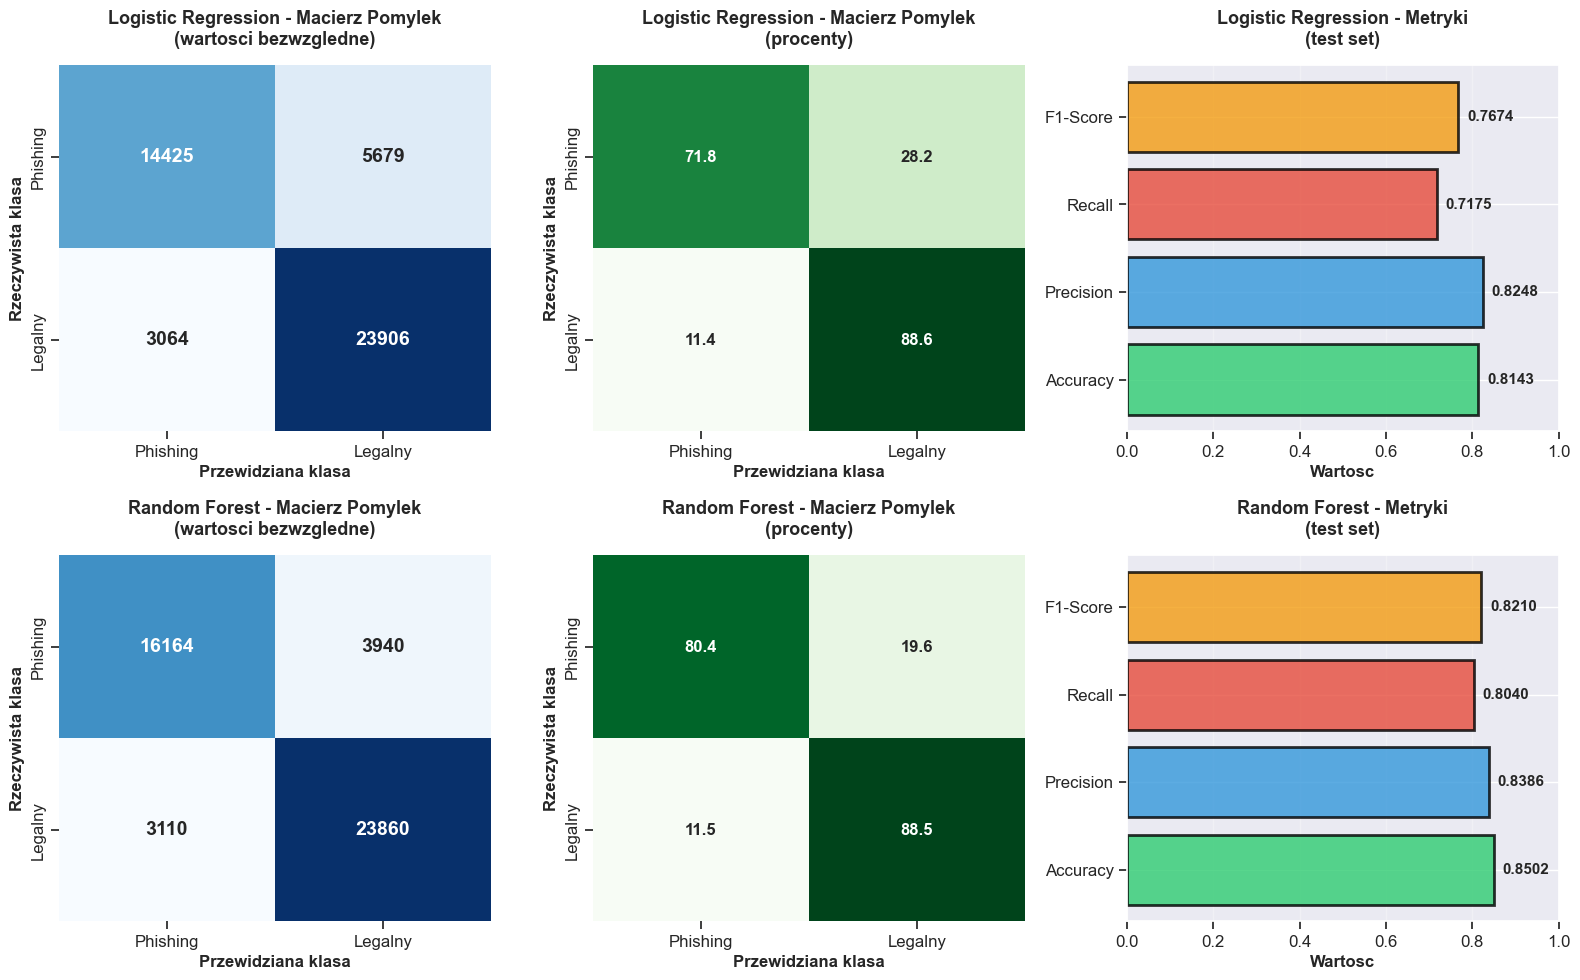

Wykresy oceny modelu zapisane


In [9]:
print("\n" + "="*80)
print("KROK 8-9: TESTOWANIE I METRYKI")
print("="*80)

# Evaluate models
results_df = evaluate_models(models, X_test, y_test)

print("\n" + "-"*80)
print("PODSUMOWANIE WYNIKÓW NA ZBIORZE TESTOWYM")
print("-"*80)
print(results_df.to_string(index=False))

best_model_idx = results_df['accuracy'].idxmax()
best_model = results_df.loc[best_model_idx, 'model']
best_acc = results_df.loc[best_model_idx, 'accuracy']

print(f"\n" + "="*80)
print(f"NAJLEPSZY MODEL: {best_model}")
print(f"Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print("="*80)

# Visualize confusion matrices and metrics
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for model_idx, (model_name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[model_idx, 0],
                xticklabels=['Phishing', 'Legalny'], yticklabels=['Phishing', 'Legalny'],
                annot_kws={'fontsize': 14, 'weight': 'bold'})
    axes[model_idx, 0].set_ylabel('Rzeczywista klasa', fontsize=12, weight='bold')
    axes[model_idx, 0].set_xlabel('Przewidziana klasa', fontsize=12, weight='bold')
    axes[model_idx, 0].set_title(f'{model_name} - Macierz Pomylek\n(wartosci bezwzgledne)', 
                                  fontsize=13, weight='bold', pad=15)
    
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens', cbar=False, ax=axes[model_idx, 1],
                xticklabels=['Phishing', 'Legalny'], yticklabels=['Phishing', 'Legalny'],
                annot_kws={'fontsize': 12, 'weight': 'bold'})
    axes[model_idx, 1].set_ylabel('Rzeczywista klasa', fontsize=12, weight='bold')
    axes[model_idx, 1].set_xlabel('Przewidziana klasa', fontsize=12, weight='bold')
    axes[model_idx, 1].set_title(f'{model_name} - Macierz Pomylek\n(procenty)', 
                                  fontsize=13, weight='bold', pad=15)
    
    metrics_data = results_df[results_df['model'] == model_name].iloc[0]
    metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    metrics_values = [
        metrics_data['accuracy'],
        metrics_data['precision_phishing'],
        metrics_data['recall_phishing'],
        metrics_data['f1_phishing']
    ]
    colors_metrics = ['#2ECC71', '#3498DB', '#E74C3C', '#F39C12']
    
    axes[model_idx, 2].barh(metrics_labels, metrics_values, color=colors_metrics, 
                                    edgecolor='black', linewidth=2, alpha=0.8)
    axes[model_idx, 2].set_xlabel('Wartosc', fontsize=12, weight='bold')
    axes[model_idx, 2].set_xlim([0, 1])
    axes[model_idx, 2].set_title(f'{model_name} - Metryki\n(test set)', 
                                  fontsize=13, weight='bold', pad=15)
    axes[model_idx, 2].grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(metrics_values):
        axes[model_idx, 2].text(v + 0.02, i, f'{v:.4f}', va='center', fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig('outputs/03_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Wykresy oceny modelu zapisane")

In [11]:
print("\n" + "="*80)
print("KROK 10: CROSS-VALIDATION (5-FOLD)")
print("="*80)

cv_results_df = run_cross_validation(X, y)

print("\n" + "-"*80)
print("WYNIKI CROSS-VALIDATION")
print("-"*80)
print(cv_results_df.to_string(index=False))

cv_accuracy = cv_results_df[cv_results_df['metric'] == 'accuracy']
print(f"\n" + "-"*80)
print("SREDNIA ACCURACY Z CV (5-fold):")
print("-"*80)
for idx, row in cv_accuracy.iterrows():
    print(f"{row['model']:25s}: {row['mean']:.4f} (+/- {row['std']:.4f})")


KROK 10: CROSS-VALIDATION (5-FOLD)

=== Cross-Validation (5-fold Stratified) ===

Logistic Regression:
  accuracy:
    Fold 1: 0.9848
    Fold 2: 0.9829
    Fold 3: 0.9857
    Fold 4: 0.9843
    Fold 5: 0.9853
    Mean: 0.9846 (+/- 0.0010)
  precision_phishing:
    Fold 1: 0.9910
    Fold 2: 0.9905
    Fold 3: 0.9917
    Fold 4: 0.9918
    Fold 5: 0.9931
    Mean: 0.9916 (+/- 0.0009)
  recall_phishing:
    Fold 1: 0.9733
    Fold 2: 0.9692
    Fold 3: 0.9748
    Fold 4: 0.9712
    Fold 5: 0.9723
    Mean: 0.9722 (+/- 0.0019)
  f1_phishing:
    Fold 1: 0.9821
    Fold 2: 0.9797
    Fold 3: 0.9832
    Fold 4: 0.9814
    Fold 5: 0.9826
    Mean: 0.9818 (+/- 0.0012)

Random Forest:
  accuracy:
    Fold 1: 0.9969
    Fold 2: 0.9967
    Fold 3: 0.9970
    Fold 4: 0.9966
    Fold 5: 0.9972
    Mean: 0.9969 (+/- 0.0002)
  precision_phishing:
    Fold 1: 0.9984
    Fold 2: 0.9986
    Fold 3: 0.9990
    Fold 4: 0.9985
    Fold 5: 0.9991
    Mean: 0.9987 (+/- 0.0003)
  recall_phishing:
    Fold 

In [13]:
print("\n" + "="*80)
print("KROK 8-9: TESTOWANIE I METRYKI")
print("="*80)

results_df = evaluate_models(models, X_test, y_test)

print("\n" + "-"*80)
print("PODSUMOWANIE WYNIKÓW NA ZBIORZE TESTOWYM")
print("-"*80)
print(results_df.to_string(index=False))

best_model_idx = results_df['accuracy'].idxmax()
best_model = results_df.loc[best_model_idx, 'model']
best_acc = results_df.loc[best_model_idx, 'accuracy']

print(f"\n" + "="*80)
print(f"NAJLEPSZY MODEL: {best_model}")
print(f"Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print("="*80)


KROK 8-9: TESTOWANIE I METRYKI

Model: Logistic Regression
Accuracy: 0.8143
Precision (phishing): 0.8248
Recall (phishing): 0.7175
F1-Score (phishing): 0.7674

Confusion Matrix:
                 Predicted Phishing  Predicted Legitimate
Actual Phishing             14425                5679
Actual Legitimate           3064                23906

Classification Report:
                  precision    recall  f1-score   support

        phishing     0.8248    0.7175    0.7674     20104
legitimate/legal     0.8080    0.8864    0.8454     26970

        accuracy                         0.8143     47074
       macro avg     0.8164    0.8020    0.8064     47074
    weighted avg     0.8152    0.8143    0.8121     47074


Model: Random Forest
Accuracy: 0.8502
Precision (phishing): 0.8386
Recall (phishing): 0.8040
F1-Score (phishing): 0.8210

Confusion Matrix:
                 Predicted Phishing  Predicted Legitimate
Actual Phishing             16164                3940
Actual Legitimate          

---
# ETAP 10: Cross-Validation

Przeprowadzamy 5-fold stratified cross-validation:
- Dane dzielone na 5 części
- Każda część raz służy jako test, pozostałe 4 części jako train
- Wynik to średnia ze wszystkich 5 przebiegów

Cross-validation daje bardziej wiarygodną ocenę modelu niż pojedynczy train/test split.


KROK 12: WAZNOSC CECH (Random Forest)

=== Feature Importance Analysis ===

Top 10 Features:
  IsHTTPS                        0.270345
  CharContinuationRate           0.133115
  NoOfSubDomain                  0.097125
  URLLength                      0.088921
  DomainLength                   0.086089
  TLDLength                      0.047753
  IsDomainIP                     0.031602
  NoOfObfuscatedChar             0.030970
  random_noise_2                 0.030724
  HasObfuscation                 0.030720

--------------------------------------------------------------------------------
TOP 10 NAJWAZNIEJSZYCH CECH
--------------------------------------------------------------------------------
 1. IsHTTPS                         27%  0.270345
 2. CharContinuationRate            13%  0.133115
 3. NoOfSubDomain                    9%  0.097125
 4. URLLength                        8%  0.088921
 5. DomainLength                     8%  0.086089
 6. TLDLength                        4%  0.04

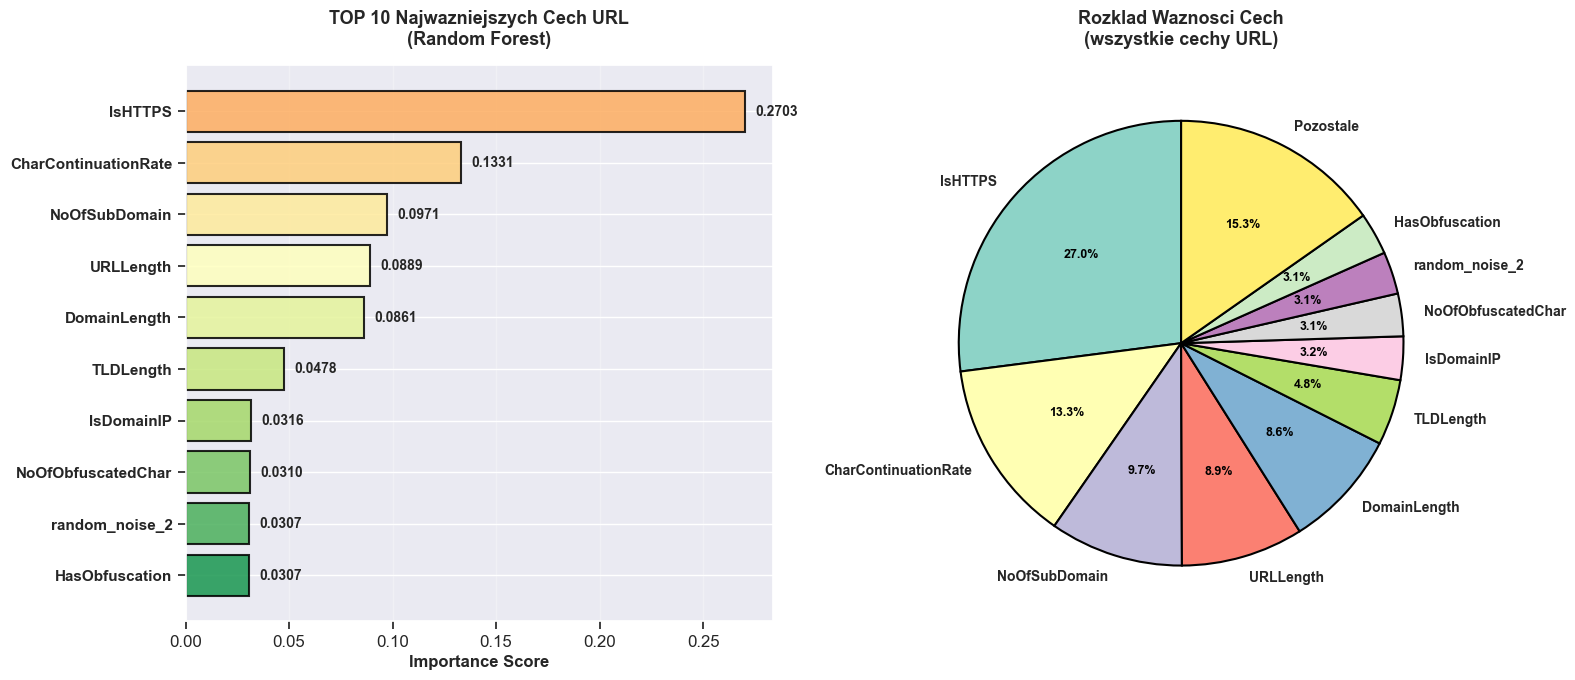

Wykresy waznosci cech zapisane


In [14]:
print("\n" + "="*80)
print("KROK 12: WAZNOSC CECH (Random Forest)")
print("="*80)

top_features_df = analyze_feature_importance(models, X_train, top_n=10)

print("\n" + "-"*80)
print("TOP 10 NAJWAZNIEJSZYCH CECH")
print("-"*80)

for idx, (_, row) in enumerate(top_features_df.head(10).iterrows(), 1):
    pct = int(row['importance'] * 100)
    print(f"{idx:2d}. {row['feature']:30s} {pct:3d}%  {row['importance']:.6f}")

# Wizualizacja waznosci cech
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_10 = top_features_df.head(10)
colors_importance = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_10)))

axes[0].barh(range(len(top_10)), top_10['importance'].values, color=colors_importance, 
                     edgecolor='black', linewidth=1.5, alpha=0.85)
axes[0].set_yticks(range(len(top_10)))
axes[0].set_yticklabels(top_10['feature'].values, fontsize=11, weight='bold')
axes[0].set_xlabel('Importance Score', fontsize=12, weight='bold')
axes[0].set_title('TOP 10 Najwazniejszych Cech URL\n(Random Forest)', fontsize=13, weight='bold', pad=15)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(top_10.iterrows()):
    axes[0].text(row['importance'] + 0.005, i, f"{row['importance']:.4f}", 
                va='center', fontsize=10, weight='bold')

all_features = top_features_df.copy()
other_importance = all_features.iloc[10:]['importance'].sum() if len(all_features) > 10 else 0

pie_labels = list(all_features.head(10)['feature'].values) + ['Pozostale']
pie_values = list(all_features.head(10)['importance'].values) + [other_importance]
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(pie_labels)))

wedges, texts, autotexts = axes[1].pie(pie_values, labels=pie_labels, autopct='%1.1f%%',
                                         colors=colors_pie, startangle=90,
                                         textprops={'fontsize': 10, 'weight': 'bold'},
                                         wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
axes[1].set_title('Rozklad Waznosci Cech\n(wszystkie cechy URL)', fontsize=13, weight='bold', pad=15)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(9)

plt.tight_layout()
plt.savefig('outputs/05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Wykresy waznosci cech zapisane")

---
# ETAP 11: ROC/AUC

Analiza ROC/AUC (Receiver Operating Characteristic / Area Under Curve):

- **ROC Curve**: Pokazuje trade-off między True Positive Rate a False Positive Rate
  - Lewa dolna część: konserwatywny model (mało false positives, ale mało true positives)
  - Prawa górna część: agresywny model (dużo true positives, ale więcej false positives)

- **AUC**: Pole pod krzywą ROC (0.5-1.0)
  - 0.5 = random classifier
  - 1.0 = perfect classifier

Krzywa ROC pozwala wybrać optymalny próg klasyfikacji dla naszych potrzeb.


KROK 11: ANALIZA ROC/AUC

Model: Logistic Regression - ROC/AUC Analysis
AUC (Phishing): 0.8707

Model: Random Forest - ROC/AUC Analysis
AUC (Phishing): 0.9062

ROC curve saved to outputs/roc_curve_baseline.png

--------------------------------------------------------------------------------
WYNIKI AUC
--------------------------------------------------------------------------------
Logistic Regression      : AUC = 0.8707
Random Forest            : AUC = 0.9062


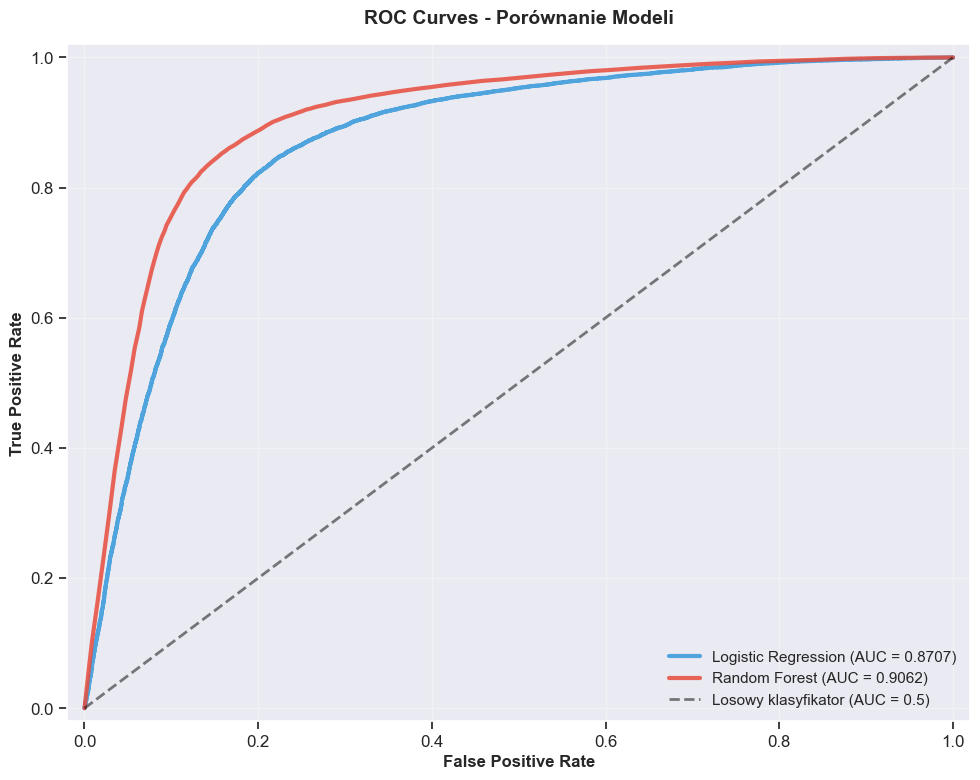


Krzywa ROC zapisana do: outputs/roc_curve_baseline.png


In [15]:
print("\n" + "="*80)
print("KROK 11: ANALIZA ROC/AUC")
print("="*80)

roc_results_df = run_roc_auc_analysis(models, X_test, y_test, experiment_name="baseline")

print("\n" + "-"*80)
print("WYNIKI AUC")
print("-"*80)
for idx, row in roc_results_df.iterrows():
    print(f"{row['model']:25s}: AUC = {row['auc_phishing']:.4f}")

# Wizualizacja ROC curves
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(10, 8))

for model_name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    color = '#3498DB' if model_name == 'Logistic Regression' else '#E74C3C'
    ax.plot(fpr, tpr, color=color, lw=3, label=f'{model_name} (AUC = {roc_auc:.4f})',
            alpha=0.85)

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Losowy klasyfikator (AUC = 0.5)', alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12, weight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, weight='bold')
ax.set_title('ROC Curves - Porównanie Modeli', fontsize=14, weight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig('outputs/roc_curve_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKrzywa ROC zapisana do: outputs/roc_curve_baseline.png")

---
# ETAP 12: Feature Importance

Analiza ważności cech z Random Forest - które cechy URL najlepiej odróżniają phishing od legalnych stron?

Random Forest pozwala nam zidentyfikować top 10 cech:
- Wyższa wartość = ważniejsza cecha
- Wartość = ile razy cecha zmniejszyła impurity w drzewach

Poniżej widzimy, które charakterystyki URL najlepiej służą do predykcji.

In [16]:
print("\n" + "="*80)
print("KROK 12: WAZNOSC CECH (Random Forest)")
print("="*80)

top_features_df = analyze_feature_importance(models, X_train, top_n=10)

print("\n" + "-"*80)
print("TOP 10 NAJWAZNIEJSZYCH CECH")
print("-"*80)

for idx, (_, row) in enumerate(top_features_df.head(10).iterrows(), 1):
    pct = int(row['importance'] * 100)
    print(f"{idx:2d}. {row['feature']:30s} {pct:3d}%  {row['importance']:.6f}")


KROK 12: WAZNOSC CECH (Random Forest)

=== Feature Importance Analysis ===

Top 10 Features:
  IsHTTPS                        0.270345
  CharContinuationRate           0.133115
  NoOfSubDomain                  0.097125
  URLLength                      0.088921
  DomainLength                   0.086089
  TLDLength                      0.047753
  IsDomainIP                     0.031602
  NoOfObfuscatedChar             0.030970
  random_noise_2                 0.030724
  HasObfuscation                 0.030720

--------------------------------------------------------------------------------
TOP 10 NAJWAZNIEJSZYCH CECH
--------------------------------------------------------------------------------
 1. IsHTTPS                         27%  0.270345
 2. CharContinuationRate            13%  0.133115
 3. NoOfSubDomain                    9%  0.097125
 4. URLLength                        8%  0.088921
 5. DomainLength                     8%  0.086089
 6. TLDLength                        4%  0.04

---
# PODSUMOWANIE PROJEKTU

In [17]:
print("\n" + "="*80)
print("PODSUMOWANIE WYNIKOW")
print("="*80)

print(f"\nDATASET:")
print(f"  Cechy URL: {X.shape[1]}")
print(f"  Calkowita liczba probek: {X.shape[0]:,}")
print(f"  Zbior treningowy: {X_train.shape[0]:,}")
print(f"  Zbior testowy: {X_test.shape[0]:,}")
print(f"  Podział: 80%/20% (stratified)")

print(f"\nMODELE:")
print(f"  1. Logistic Regression (model bazowy)")
print(f"  2. Random Forest (100 drzew, bez tuningu)")

print(f"\nWYNIKI NA ZBIORZE TESTOWYM:")
for idx, row in results_df.iterrows():
    print(f"\n  {row['model']}:")
    print(f"    Accuracy:  {row['accuracy']:.4f} ({row['accuracy']*100:.2f}%)")
    print(f"    Precision: {row['precision_phishing']:.4f}")
    print(f"    Recall:    {row['recall_phishing']:.4f}")
    print(f"    F1-Score:  {row['f1_phishing']:.4f}")

print(f"\n" + "-"*80)
print(f"ZWYCIEZCA: {best_model}")
print(f"Najlepsza accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print("-"*80)

print(f"\nOUTPUTY:")
print(f"  - Krzywa ROC: outputs/roc_curve_baseline.png")
print(f"  - Metryki ewaluacji (wyżej)")
print(f"  - Ważność cech (wyżej)")
print(f"  - Cross-validation (wyżej)")

print(f"\n" + "="*80)
print("ANALIZA ZAKONCZENA POMYSLNIE")
print("="*80)


PODSUMOWANIE WYNIKOW

DATASET:
  Cechy URL: 10
  Calkowita liczba probek: 235,370
  Zbior treningowy: 188,296
  Zbior testowy: 47,074
  Podział: 80%/20% (stratified)

MODELE:
  1. Logistic Regression (model bazowy)
  2. Random Forest (100 drzew, bez tuningu)

WYNIKI NA ZBIORZE TESTOWYM:

  Logistic Regression:
    Accuracy:  0.8143 (81.43%)
    Precision: 0.8248
    Recall:    0.7175
    F1-Score:  0.7674

  Random Forest:
    Accuracy:  0.8502 (85.02%)
    Precision: 0.8386
    Recall:    0.8040
    F1-Score:  0.8210

--------------------------------------------------------------------------------
ZWYCIEZCA: Random Forest
Najlepsza accuracy: 0.8502 (85.02%)
--------------------------------------------------------------------------------

OUTPUTY:
  - Krzywa ROC: outputs/roc_curve_baseline.png
  - Metryki ewaluacji (wyżej)
  - Ważność cech (wyżej)
  - Cross-validation (wyżej)

ANALIZA ZAKONCZENA POMYSLNIE
